# 01 · CORD-19 Dataset Statistics
Full corpus statistics. Run once. Output feeds Section 4.1 of paper.

In [1]:

import pandas as pd
import matplotlib.pyplot as plt

META = "../../1_data/raw/metadata.csv"
df = pd.read_csv(META, low_memory=False)
print(f"Total rows : {len(df):,}")
print(f"Columns    : {list(df.columns)}")


Total rows : 1,056,660
Columns    : ['cord_uid', 'sha', 'source_x', 'title', 'doi', 'pmcid', 'pubmed_id', 'license', 'abstract', 'publish_time', 'authors', 'journal', 'mag_id', 'who_covidence_id', 'arxiv_id', 'pdf_json_files', 'pmc_json_files', 'url', 's2_id']


In [2]:

# Missing data audit
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
audit = pd.DataFrame({"missing": missing, "pct": missing_pct})
print(audit[audit['missing'] > 0].sort_values('pct', ascending=False))


                  missing    pct
mag_id            1056660  100.0
arxiv_id          1042411   98.7
pmc_json_files     740918   70.1
sha                682894   64.6
pdf_json_files     682894   64.6
pmcid              667089   63.1
who_covidence_id   573725   54.3
pubmed_id          557728   52.8
doi                399880   37.8
url                369726   35.0
abstract           235544   22.3
journal             87322    8.3
s2_id               80192    7.6
authors             23869    2.3
publish_time         1814    0.2
title                 503    0.0


Year distribution (parseable rows):
year
2015.0      3461
2016.0      3944
2017.0      3691
2018.0      3982
2019.0      5630
2020.0    164751
2021.0    219516
2022.0     85310
2023.0         1
2024.0         1
Name: count, dtype: int64

Parseable date rows: 518,871 / 1,056,660


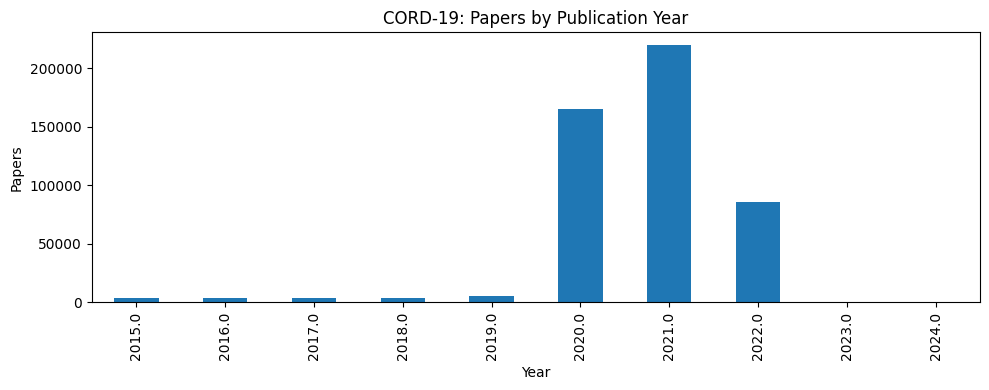

In [3]:

# Publication year distribution
df['year'] = pd.to_datetime(df['publish_time'], errors='coerce').dt.year
year_counts = df['year'].value_counts().sort_index()
print("Year distribution (parseable rows):")
print(year_counts[year_counts.index >= 2015])
print(f"\nParseable date rows: {df['year'].notna().sum():,} / {len(df):,}")

fig, ax = plt.subplots(figsize=(10,4))
year_counts[year_counts.index >= 2015].plot(kind='bar', ax=ax)
ax.set_title("CORD-19: Papers by Publication Year"); ax.set_xlabel("Year"); ax.set_ylabel("Papers")
plt.tight_layout(); plt.savefig("../../1_data/processed/dataset_overview_full.png", dpi=150)
plt.show()


In [4]:

# Abstract length stats
df_abs = df[df['abstract'].notna()].copy()
df_abs['abs_len'] = df_abs['abstract'].str.len()
print(f"Papers with abstract : {len(df_abs):,} ({len(df_abs)/len(df)*100:.1f}%)")
print(f"Median abstract len  : {df_abs['abs_len'].median():.0f} chars")
print(f"p95 abstract len     : {df_abs['abs_len'].quantile(0.95):.0f} chars")
print(f"p99 abstract len     : {df_abs['abs_len'].quantile(0.99):.0f} chars")


Papers with abstract : 821,116 (77.7%)
Median abstract len  : 1437 chars
p95 abstract len     : 2493 chars
p99 abstract len     : 3353 chars


In [5]:

# Paper for Section 4.1 stats
print("=== PAPER SECTION 4.1 NUMBERS ===")
print(f"Full CORD-19 corpus  : {len(df):,} papers")
print(f"Papers with abstract : {df_abs.__len__():,} ({len(df_abs)/len(df)*100:.1f}%)")
pdf_avail = df['pdf_json_files'].notna().sum()
print(f"Papers with full PDF : {pdf_avail:,} ({pdf_avail/len(df)*100:.1f}%)")


=== PAPER SECTION 4.1 NUMBERS ===
Full CORD-19 corpus  : 1,056,660 papers
Papers with abstract : 821,116 (77.7%)
Papers with full PDF : 373,766 (35.4%)
